In [1]:
!pip install pandas matplotlib seaborn scikit-learn numpy==1.26.4 -q


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
!pip install kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumithsingh/blood-cell-images-for-cancer-detection")

print("Path to dataset files:", path)

  Obtaining dependency information for kagglehub from https://files.pythonhosted.org/packages/6a/26/848411b6bef16d21d5132669cde3ff1ec018ebae601ea733a8d4a093a40e/kagglehub-0.4.1-py3-none-any.whl.metadata
  Obtaining dependency information for kagglesdk<1.0,>=0.1.14 from https://files.pythonhosted.org/packages/1c/d8/71a8b9115ed2cf8b487c8976e66678311e82c73980e103eda15623abd6a5/kagglesdk-0.1.15-py3-none-any.whl.metadata
  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/d0/30/dc54f88dd4a2b5dc8a0279bdd7270e735851848b762aeb1c1184ed1f6b14/tqdm-4.67.1-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] T

100%|██████████| 122M/122M [00:01<00:00, 105MB/s]  

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sumithsingh/blood-cell-images-for-cancer-detection/versions/2


In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import ParameterGrid
import warnings
from tensorflow.keras.layers import GlobalAveragePooling2D
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import random

warnings.filterwarnings('ignore')

2026-01-21 15:23:46.144397: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-21 15:23:46.173993: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-21 15:23:46.174016: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-21 15:23:46.174037: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-21 15:23:46.180752: I tensorflow/core/platform/cpu_feature_g

In [4]:
path = "/root/.cache/kagglehub/datasets/sumithsingh/blood-cell-images-for-cancer-detection/versions/2/"
print(os.listdir(path))

['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']


(363, 360, 3)


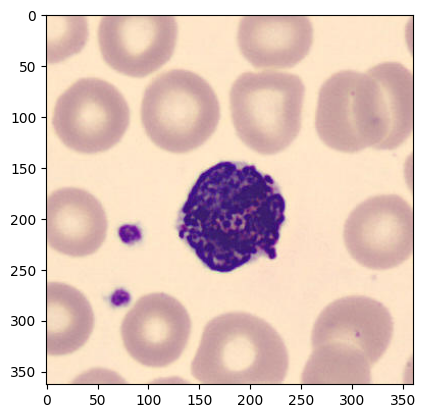

In [5]:
image_path = os.path.join(path, "basophil", "BA_100102.jpg")

try:
  img = mpimg.imread(image_path)
  plt.imshow(img)
  print(img.shape)
  plt.show()

except FileNotFoundError:
  print(f"Image file not found at: {image_path}")
  print("List of files in the basophil directory:")
  !ls basophil

In [6]:
data = []
directories = ['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']

for directory in directories:
  directory_path = os.path.join(path, directory)
  for filename in os.listdir(directory_path):
    if filename.endswith(('.jpg')):
      image_path = os.path.join(directory_path, filename)
      data.append({'Image': image_path, 'Target': directory})

df = pd.DataFrame(data)
print(df.shape)

(5000, 2)


In [7]:
dfs = {}
# Iterate through unique targets
for target in df['Target'].unique():
  # Filter DataFrame for the current target
  df_target = df[df['Target'] == target]
  # Split into train, validation, and test sets
  train_df, temp_df = train_test_split(df_target, train_size=700, random_state=42, shuffle=True)
  val_df, test_df = train_test_split(temp_df, train_size=0.5, random_state=42, shuffle=True)

  # Store the DataFrames in the dictionary
  dfs[target] = {'train': train_df, 'val': val_df, 'test': test_df}

train_df = pd.concat([dfs[target]['train'] for target in dfs])
val_df = pd.concat([dfs[target]['val'] for target in dfs])
test_df = pd.concat([dfs[target]['test'] for target in dfs])

# Print the shapes of the resulting DataFrames
print("Train DataFrame shape:", train_df.shape)
print("Validation DataFrame shape:", val_df.shape)
print("Test DataFrame shape:", test_df.shape)

Train DataFrame shape: (3500, 2)
Validation DataFrame shape: (750, 2)
Test DataFrame shape: (750, 2)


In [8]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    rescale=1./255
)


train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="Image",
    y_col="Target",
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    color_mode='grayscale'
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="Image",
    y_col="Target",
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    color_mode='grayscale'
)

test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="Image",
    y_col="Target",
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    color_mode='grayscale'
)

Found 3500 validated image filenames belonging to 5 classes.
Found 750 validated image filenames belonging to 5 classes.
Found 750 validated image filenames belonging to 5 classes.


In [4]:
def create_model(input_shape=(128, 128, 1)):
    """
    Create a CNN model with fixed architecture

    Args:
        input_shape: Shape of input images, default (128, 128, 1)

    Returns:
        Compiled Keras model
    """
    model = Sequential([
        # First convolutional block
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # Second convolutional block
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # Third convolutional block
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # Flatten and dense layers
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(5, activation='softmax')
    ])

    # Compile model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def train_model(model, train_generator, val_generator, epochs=30):
    """
    Train the model with early stopping and learning rate reduction

    Args:
        model: Compiled Keras model
        train_generator: Training data generator
        val_generator: Validation data generator
        epochs: Maximum number of epochs to train

    Returns:
        Training history and trained model
    """
    # Define callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-6
        )
    ]

    # Train the model
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    return history, model

def plot_training_history(history):
    """
    Plot training history including accuracy and loss curves

    Args:
        history: Keras training history object
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Loss plot
    ax2.plot(history.history['loss'], label='Training')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred):
    """
    Plot confusion matrix with class labels

    Args:
        y_true: True labels
        y_pred: Predicted labels
    """
    # Define class labels
    class_labels = ['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Create figure and axes
    plt.figure(figsize=(10, 8))

    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels,
                yticklabels=class_labels)

    plt.title('Confusion Matrix - Blood Cell Cancer')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

def print_classification_metrics(y_true, y_pred):
    """
    Print classification report with class labels

    Args:
        y_true: True labels
        y_pred: Predicted labels
    """
    class_labels = ['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_labels,
        digits=4
    )
    print("\nClassification Report:")
    print(report)

def evaluate_model(model, test_generator):
    """
    Evaluate the model on test data

    Args:
        model: Trained Keras model
        test_generator: Test data generator

    Returns:
        Test loss, accuracy, and predicted classes
    """
    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)

    # Get predictions
    predictions = model.predict(test_generator)
    predicted_classes = predictions.argmax(axis=1)

    return test_loss, test_accuracy, predicted_classes

In [10]:
tf.random.set_seed(42)
np.random.seed(42)

# Define parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 30

# Create and compile model
print("Creating model...")
model = create_model(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1))
model.summary()

# Train model
print("\nTraining model...")
history, trained_model = train_model(
    model,
    train_generator,
    val_generator,
    epochs=EPOCHS
)

# Evaluate model
print("\nEvaluating model...")
test_loss, test_accuracy, predictions = evaluate_model(trained_model, test_generator)
print(f'Test accuracy: {test_accuracy:.4f}')

Creating model...


2026-01-21 15:29:55.913657: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2303] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-01-21 15:29:55.930950: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2303] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-01-21 15:29:56.110345: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29815 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0001:46:00.0, compute capability: 12.0


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      320       
                                                                 
 batch_normalization (Batch  (None, 126, 126, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 61, 61, 64)        256       
 chNormalization)                                                
                                                        

2026-01-21 15:30:08.953873: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8905
2026-01-21 15:30:23.876841: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-01-21 15:30:23.885127: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:231] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
2026-01-21 15:30:23.885144: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:234] Used ptxas at /usr/local/cuda-11.8/bin/ptxas
2026-01-21 15:30:23.885229: W tensorflow/compiler/xla/stream_executor/gpu/redzone_allocator.cc:322] UNIMPLEMENTED: /usr/local/cuda-11.8/bin/ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2026-01-21 15:31:30.327349: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot 

110/110 [==============================] - 196s 235ms/step - loss: 0.8240 - accuracy: 0.7317 - val_loss: 30.0171 - val_accuracy: 0.2000 - lr: 0.0010
Epoch 2/30
110/110 [==============================] - 10s 91ms/step - loss: 0.3681 - accuracy: 0.8786 - val_loss: 34.5466 - val_accuracy: 0.2000 - lr: 0.0010
Epoch 3/30
110/110 [==============================] - 10s 90ms/step - loss: 0.2372 - accuracy: 0.9223 - val_loss: 34.3984 - val_accuracy: 0.2000 - lr: 0.0010
Epoch 4/30
110/110 [==============================] - 10s 93ms/step - loss: 0.2264 - accuracy: 0.9297 - val_loss: 11.3362 - val_accuracy: 0.2000 - lr: 0.0010
Epoch 5/30
110/110 [==============================] - 11s 96ms/step - loss: 0.2246 - accuracy: 0.9254 - val_loss: 1.0361 - val_accuracy: 0.6240 - lr: 0.0010
Epoch 6/30
110/110 [==============================] - 11s 96ms/step - loss: 0.1986 - accuracy: 0.9340 - val_loss: 6.0751 - val_accuracy: 0.3720 - lr: 0.0010
Epoch 7/30
110/110 [==============================] - 11s 96ms/

In [2]:
model = tf.keras.models.load_model(r"C:\Users\batuh\OneDrive\Desktop\Mediain-New-Models\Blood Cell Cancer\HemaDeep.h5")
print(f"Modelin beklediği giriş boyutu: {model.input_shape}")

Modelin beklediği giriş boyutu: (None, 128, 128, 1)


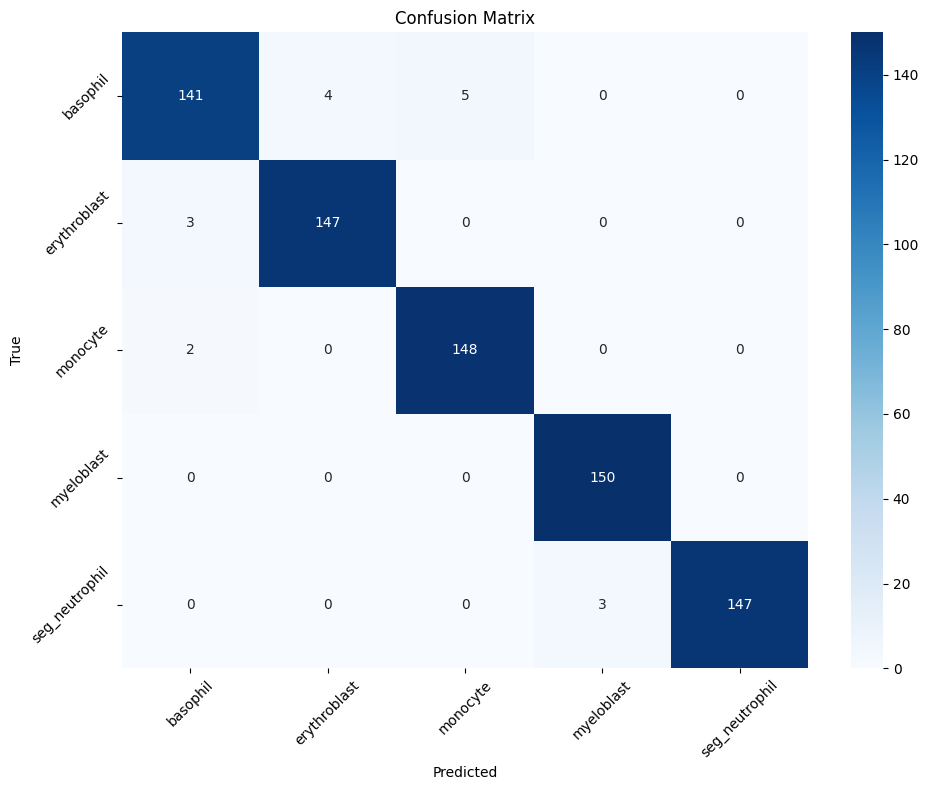

In [6]:
from IPython.display import Image, display
result_image = r"C:\Users\batuh\OneDrive\Desktop\Mediain-New-Models\Blood Cell Cancer\TEST\__results___19_0.png"
# Dosya yolunu belirterek resmi göster
display(Image(filename=result_image, width=300, height=300))

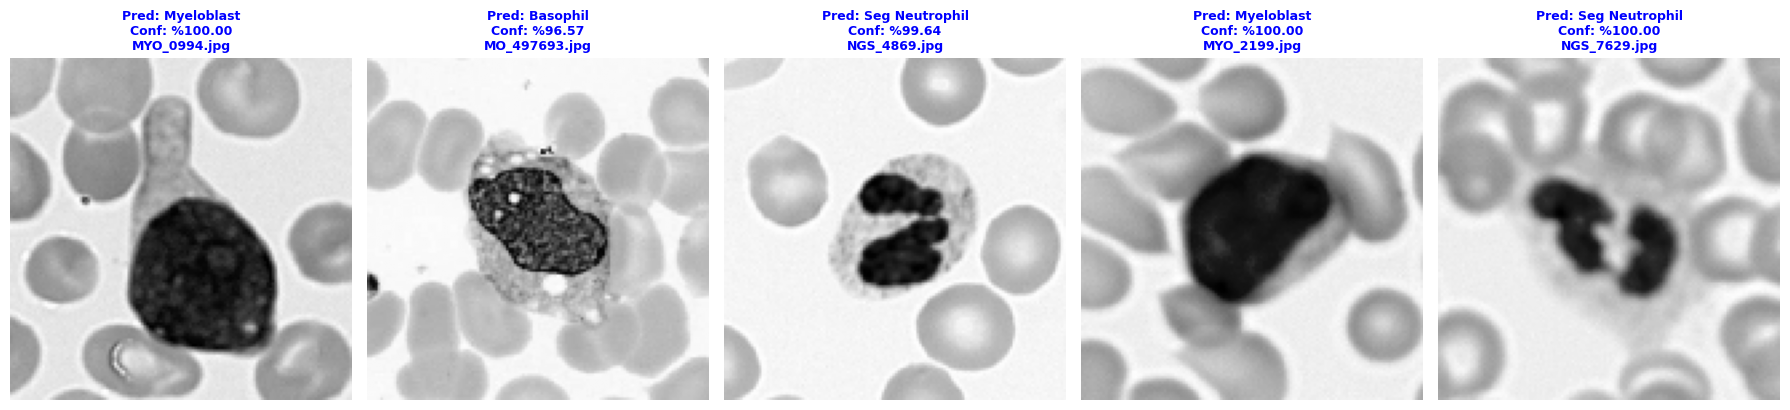

In [ ]:
data_path = r"C:\Users\batuh\OneDrive\Desktop\Mediain-New-Models\Blood_Cell_Cancer\Dataset"
model_path = r"C:\Users\batuh\OneDrive\Desktop\Mediain-New-Models\Blood_Cell_Cancer\HemaDeep.h5"

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import tensorflow as tf
from tensorflow.keras.models import load_model
import random

data = [] 
dataset_path = data_path
for i in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, i) 
    for j in os.listdir(class_path):
        image_path = os.path.join(class_path, j)
        data.append(image_path)
random_images = random.sample(data, 5)
model = load_model(model_path)


plt.figure(figsize=(18, 5)) 
for i, img_path in enumerate(random_images):
    # Grayscale olarak yükle
    img = image.load_img(img_path, target_size=(128, 128), color_mode='grayscale')
    img_array = image.img_to_array(img)
    img_array_rescaled = img_array / 255.0
    img_array_batch = np.expand_dims(img_array_rescaled, axis=0)

    # Tahmin
    y_pred_prob = model.predict(img_array_batch, verbose=0)
    y_pred_class = np.argmax(y_pred_prob, axis=1)[0]
    
    class_indices = {0: 'Basophil', 1: 'Erythroblast', 2: 'Monocyte', 3: 'Myeloblast', 4: 'Seg Neutrophil'}
    predicted_class_name = class_indices.get(y_pred_class, f"Sınıf {y_pred_class}")
    confidence = np.max(y_pred_prob) * 100
    img_name = os.path.basename(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img_array.squeeze(), cmap='gray')
    plt.axis('off')
    plt.title(f"Pred: {predicted_class_name}\nConf: %{confidence:.2f}\n{img_name}", 
              fontsize=9, color='blue', fontweight='bold')
plt.tight_layout()
plt.show()